In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("Bank marketing.csv")

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   age        45211 non-null  int64
 1   job        45211 non-null  str  
 2   marital    45211 non-null  str  
 3   education  45211 non-null  str  
 4   default    45211 non-null  str  
 5   balance    45211 non-null  int64
 6   housing    45211 non-null  str  
 7   loan       45211 non-null  str  
 8   contact    45211 non-null  str  
 9   day        45211 non-null  int64
 10  month      45211 non-null  str  
 11  duration   45211 non-null  int64
 12  campaign   45211 non-null  int64
 13  pdays      45211 non-null  int64
 14  previous   45211 non-null  int64
 15  poutcome   45211 non-null  str  
 16  y          45211 non-null  str  
dtypes: int64(7), str(10)
memory usage: 8.1 MB


In [4]:
df.shape

(45211, 17)

In [5]:
df.describe()

,age,balance,day,duration,campaign,pdays,previous
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,40.936210,1362.272058,15.806419,258.163080,2.763841,40.197828,0.580323
std,10.618762,3044.765829,8.322476,257.527812,3.098021,100.128746,2.303441
min,18.000000,-8019.000000,1.000000,0.000000,1.000000,-1.000000,0.000000
25%,33.000000,72.000000,8.000000,103.000000,1.000000,-1.000000,0.000000
50%,39.000000,448.000000,16.000000,180.000000,2.000000,-1.000000,0.000000
75%,48.000000,1428.000000,21.000000,319.000000,3.000000,-1.000000,0.000000
max,95.000000,102127.000000,31.000000,4918.000000,63.000000,871.000000,275.000000


In [6]:
df.isnull().sum()

age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df.dtypes

age          int64
job            str
marital        str
education      str
default        str
balance      int64
housing        str
loan           str
contact        str
day          int64
month          str
duration     int64
campaign     int64
pdays        int64
previous     int64
poutcome       str
y              str
dtype: object

In [9]:
df['duration'] = (df['duration'] / 60).round(2)

In [10]:
df.rename(columns={'duration': 'duration_minutes'}, inplace=True)

In [11]:
categorical_cols = df.select_dtypes(include='object').columns
numerical_cols = df.select_dtypes(include='number').columns

print("Categorical:", list(categorical_cols))
print("Numerical:", list(numerical_cols))

Categorical: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome', 'y']
Numerical: ['age', 'balance', 'day', 'duration_minutes', 'campaign', 'pdays', 'previous']


C:\Users\Dell\AppData\Local\Temp\ipykernel_1600\1274353523.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include='object').columns


## Univeriate analysis

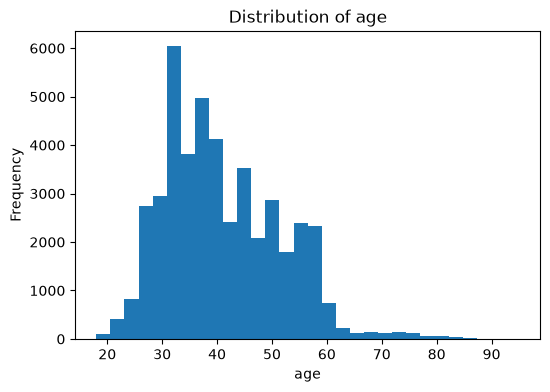

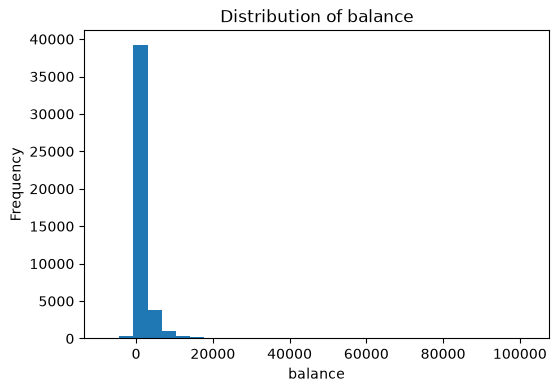

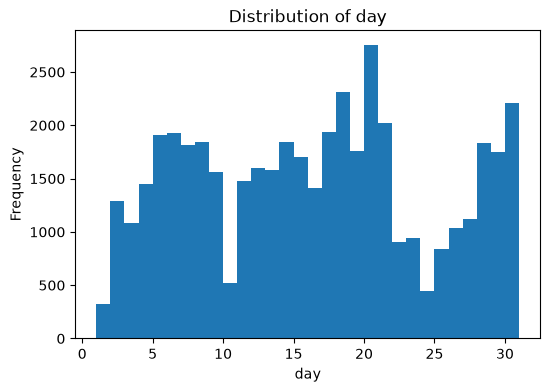

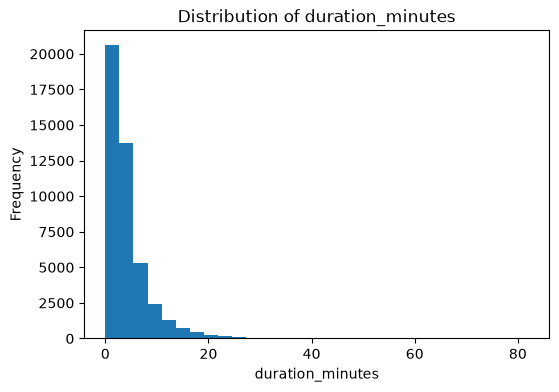

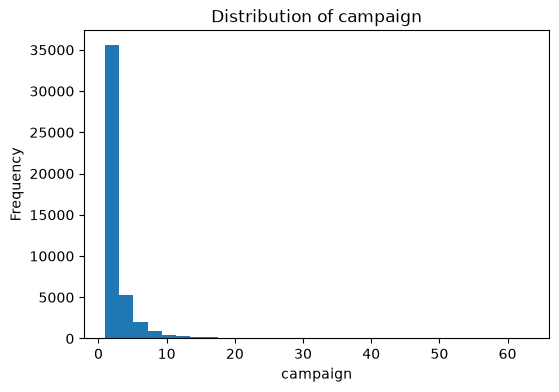

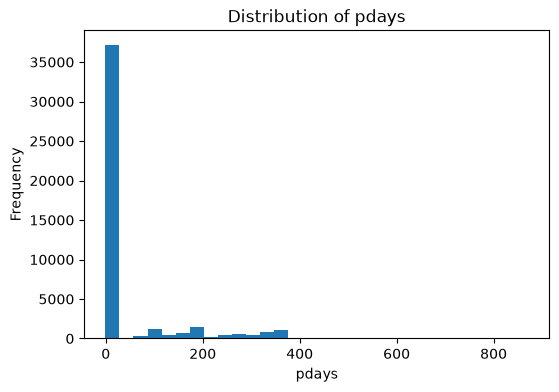

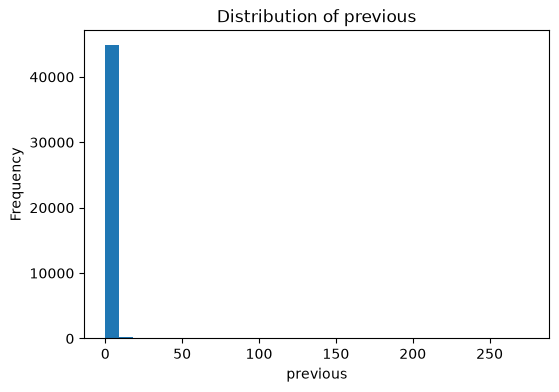

In [12]:
import matplotlib.pyplot as plt

for col in numerical_cols:
    plt.figure(figsize=(6,4))
    plt.hist(df[col].dropna(), bins=30)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

In [13]:
for col in categorical_cols:
    print("\n", col)
    print(df[col].value_counts())


 job
job
blue-collar      9732
management       9458
technician       7597
admin.           5171
services         4154
retired          2264
self-employed    1579
entrepreneur     1487
unemployed       1303
housemaid        1240
student           938
unknown           288
Name: count, dtype: int64

 marital
marital
married     27214
single      12790
divorced     5207
Name: count, dtype: int64

 education
education
secondary    23202
tertiary     13301
primary       6851
unknown       1857
Name: count, dtype: int64

 default
default
no     44396
yes      815
Name: count, dtype: int64

 housing
housing
yes    25130
no     20081
Name: count, dtype: int64

 loan
loan
no     37967
yes     7244
Name: count, dtype: int64

 contact
contact
cellular     29285
unknown      13020
telephone     2906
Name: count, dtype: int64

 month
month
may    13766
jul     6895
aug     6247
jun     5341
nov     3970
apr     2932
feb     2649
jan     1403
oct      738
sep      579
mar      477
dec      214
Nam

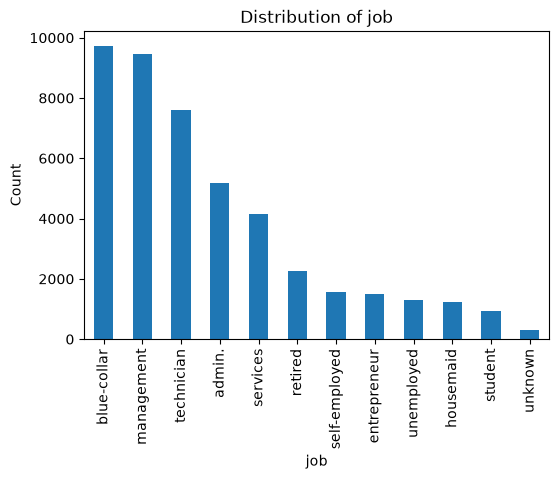

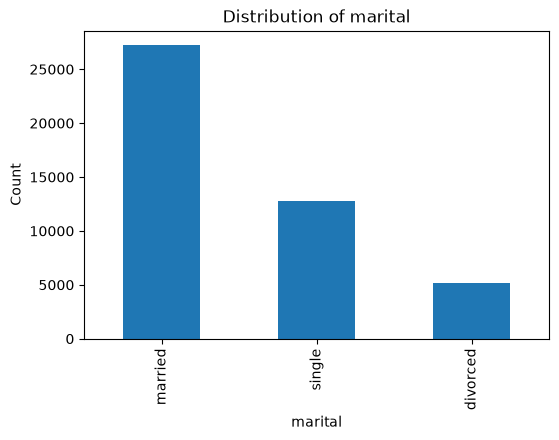

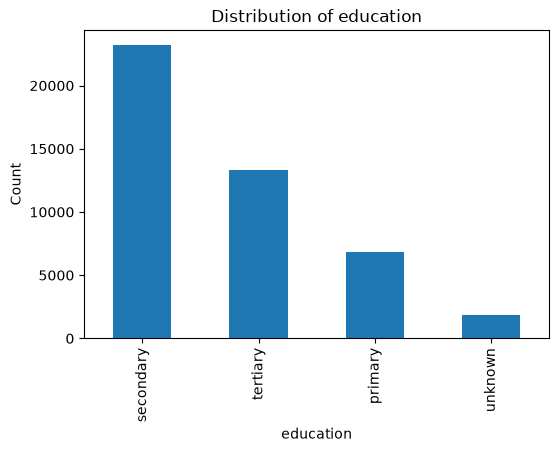

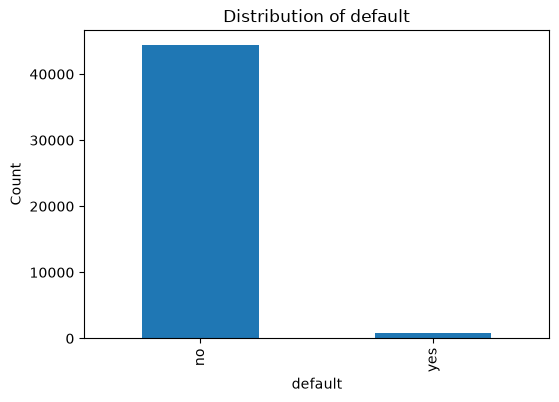

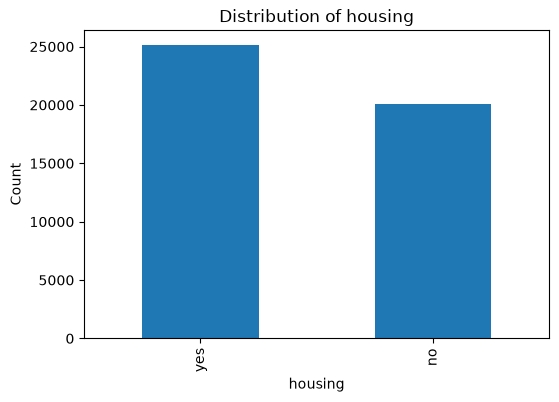

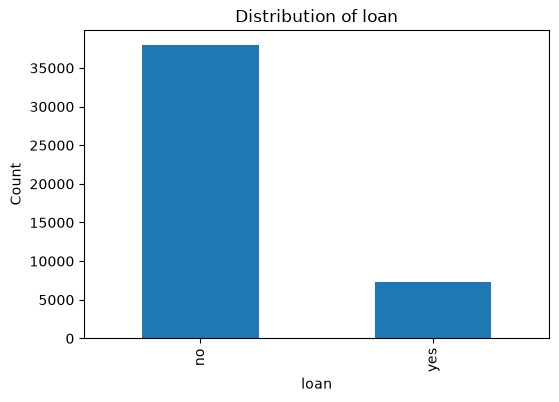

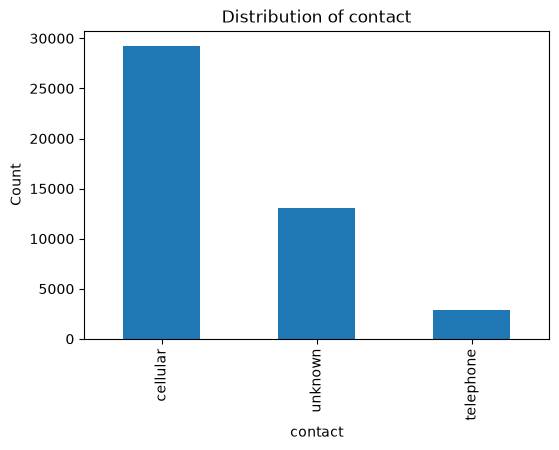

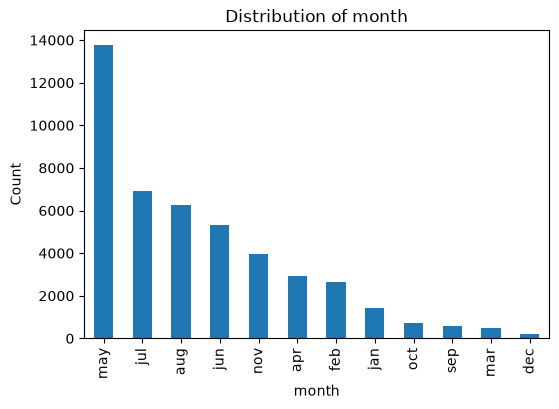

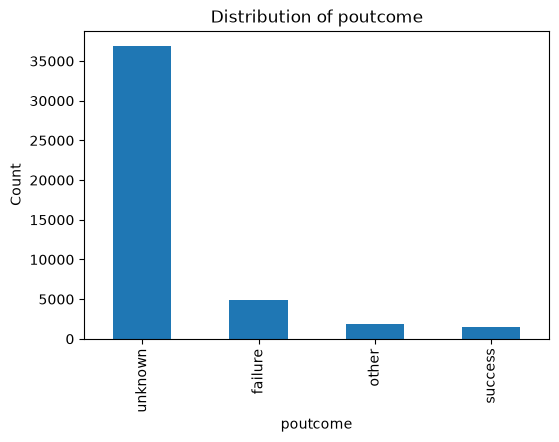

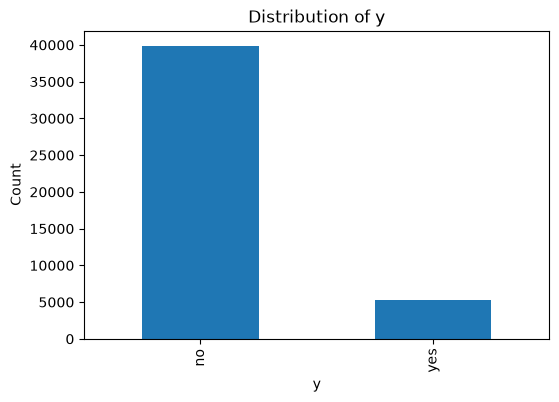

In [14]:
for col in categorical_cols:
    df[col].value_counts().plot(kind='bar', figsize=(6,4))
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.show()

## Bivariate analysis

#### Job vs balance

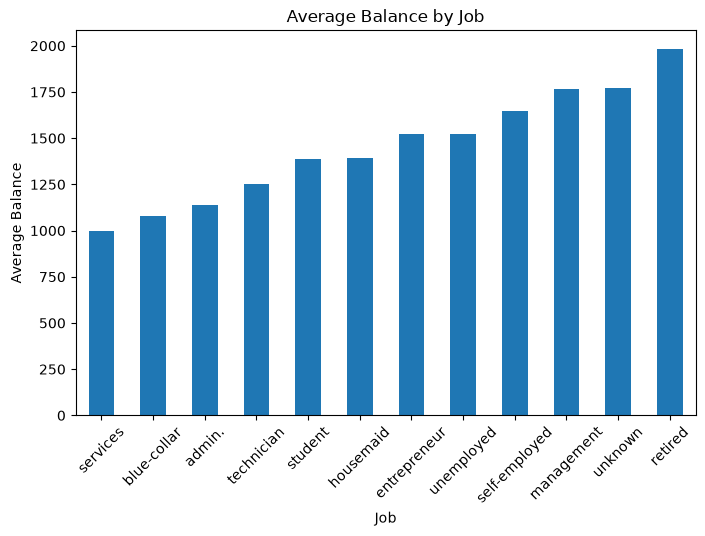

In [15]:
df.groupby('job')['balance'].mean().sort_values().plot(kind='bar', figsize=(8,5))
plt.title('Average Balance by Job')
plt.xlabel('Job')
plt.ylabel('Average Balance')
plt.xticks(rotation=45)
plt.show()

#### Education vs balance

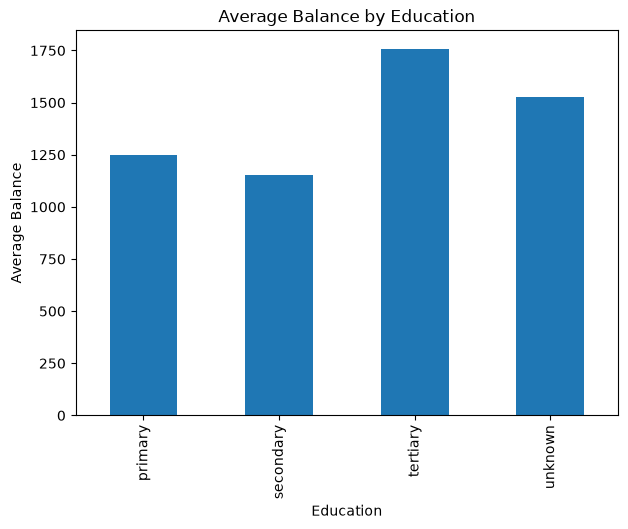

In [16]:
df.groupby('education')['balance'].mean().plot(kind='bar', figsize=(7,5))
plt.title('Average Balance by Education')
plt.xlabel('Education')
plt.ylabel('Average Balance')
plt.show()

#### Age vs balance

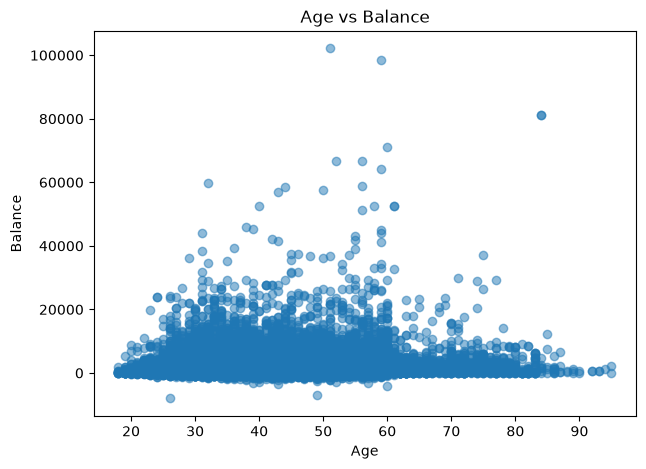

In [17]:
plt.figure(figsize=(7,5))
plt.scatter(df['age'], df['balance'], alpha=0.5)
plt.xlabel('Age')
plt.ylabel('Balance')
plt.title('Age vs Balance')
plt.show()

#### Age vs duration minutes

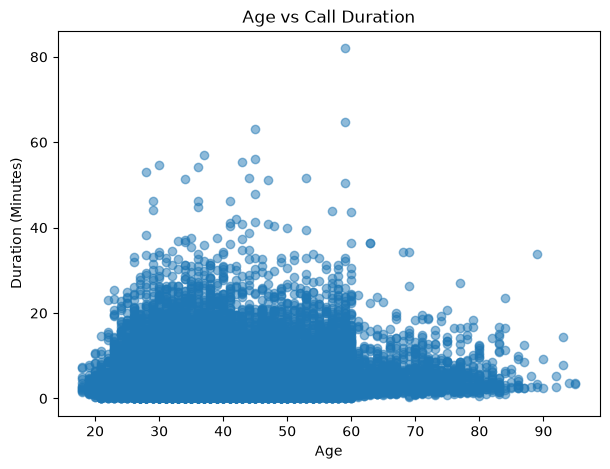

In [18]:
plt.figure(figsize=(7,5))
plt.scatter(df['age'], df['duration_minutes'], alpha=0.5)
plt.xlabel('Age')
plt.ylabel('Duration (Minutes)')
plt.title('Age vs Call Duration')
plt.show()

### Multivariate analysis

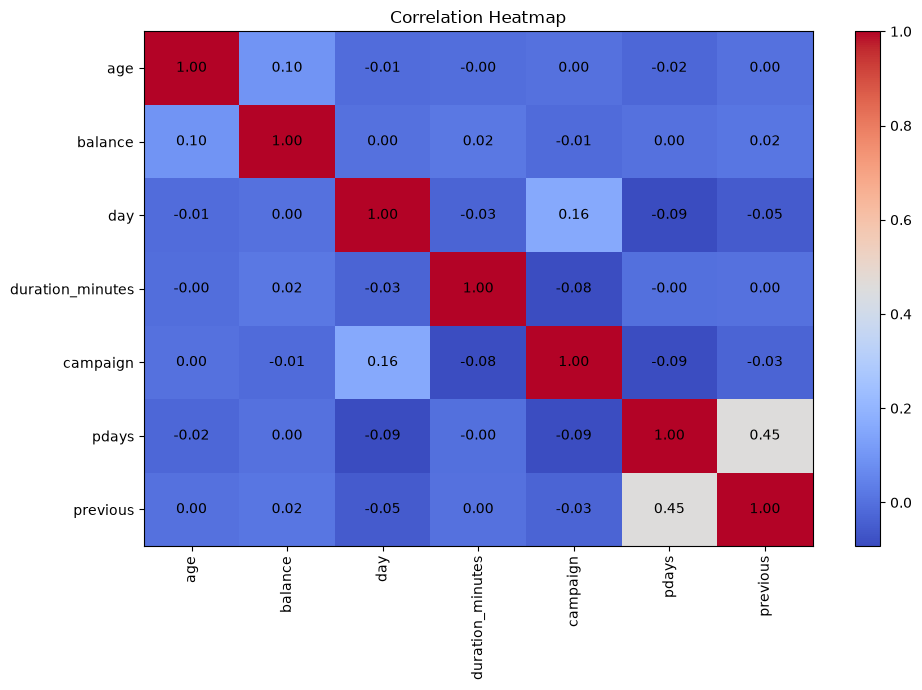

In [19]:
import matplotlib.pyplot as plt

numerical_cols = df.select_dtypes(include='number').columns
corr = df[numerical_cols].corr()

plt.figure(figsize=(10, 7))
plt.imshow(corr, cmap='coolwarm', aspect='auto')
plt.colorbar()

plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)

# Display correlation values
for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        plt.text(j, i, f'{corr.iloc[i, j]:.2f}',
                 ha='center', va='center')

plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

In [21]:
df.to_csv("bank_marketing_eda.csv", index=False)

In [22]:
import os

os.path.exists("bank_marketing_eda.csv")

True

### Insights

- The dataset contains customers from different age groups, occupations, marital statuses, and education levels, with middle-aged and married      customers forming a large portion of the dataset.
- The subscription outcome is imbalanced, with most customers not subscribing to the term deposit and a smaller proportion subscribing.
Call duration shows a strong association with subscription: customers involved in longer conversations tend to have higher subscription rates.
- Previous campaign outcome is an important indicator; customers with a previously successful outcome tend to show higher subscription rates.
- Students show a relatively higher subscription tendency compared with several other job categories.
- Customers with no housing loan and no personal loan generally show better subscription rates.
- Customers with no previous default tend to have a better response to the campaign.
- The communication method also shows differences in subscription behavior, with cellular contact being widely used.
- Campaign-related variables such as number of contacts and previous interactions provide useful information about customer response.
- The correlation analysis shows that most numerical variables have weak relationships with each other, suggesting limited multicollinearity.
- Overall, the analysis indicates that customer characteristics, financial status, previous campaign history, and current campaign interaction are useful for understanding subscription behavior.


### Target Variable Identification

The target variable is identified based on the business objective and the meaning of the dataset columns.

- The `y` column represents the final outcome of the marketing campaign.
- It indicates whether the customer subscribed to a term deposit.
- `yes` represents customers who subscribed.
- `no` represents customers who did not subscribe.
- Since `y` represents the outcome to be predicted, it is considered the target variable.